In [ ]:
from pathlib import Path
import os
import sys

REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "tealeaf").is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)


In [1]:
import pandas as pd
import collections

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE # umap doesn't load :(

import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from tealeaf import calcutta
import scipy.sparse as sp
import scipy.io
import re

from importlib import reload
reload(calcutta)
sparse_sum = calcutta.sparse_sum

import seaborn as sns
import plotnine as p9
p9.theme_set(p9.theme_bw)

In [2]:
import umap

## Check coverage per cell

This code should all also work when using t2t_dedup (i.e. isoform level counts). 

In [3]:
data_dir = Path("/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice")
#salmon_dir = data_dir / "salmon_spliceu" / "out_permit_known" / "quant_t2t_dedup" 
salmon_dir = data_dir / "salmon_per_sublib"# / "out_permit_known" / "quant_spliceu_t2g"

cells_meta = {}

srrdirs = [ item for item in salmon_dir.iterdir() if item.is_dir() ]
for srrdir in srrdirs: 
    cells_meta[srrdir.name] = pd.read_csv(srrdir / "out_permit_known" / "quant_spliceu_t2g" / "featureDump.txt", sep = "\t")
    cells_meta[srrdir.name]["sublibrary"] = srrdir.name
    
cells_meta = pd.concat(cells_meta.values(), axis=0)
#cells_meta = pd.read_csv(salmon_dir / "featureDump.txt", sep = "\t")
#cells_meta.shape # 192k cells in OG split-seq, 79k in microglia_less (30k according to paper, but these might be "half cells")
# 744k when using known BCs (!) for microglialess

In [4]:
plt.hist(np.log10(cells_meta.DeduplicatedReads), 100)
plt.xlabel("log10(deduped reads)")

Text(0.5, 0, 'log10(deduped reads)')

I think just the fat right tail are the real cells. 

In [5]:
# get the Parse/V2 barcodes (thanks Scott!) 
parse_meta_dir = Path("/gpfs/commons/groups/knowles_lab/data/sc/splitpool/Parse_meta")
ligation_BCs_v2 = pd.read_csv(parse_meta_dir / "Parse_ligation_barcodes.txt", sep = "\t", header = None)
ligation_BCs_v2 = ligation_BCs_v2[0].tolist() 
ligation_BCs_v2[:5]

['AACGTGAT', 'AAACATCG', 'ATGCCTAA', 'AGTGGTCA', 'ACCACTGT']

In [6]:
rt_BCs_v2 = pd.read_csv(parse_meta_dir / "Parse_RT_barcodes.txt", sep = "\t", header = None)
rt_BCs_v2 = rt_BCs_v2[0].tolist() 
len(rt_BCs_v2) # 96 barcodes (the order matters!)

96

In [7]:
# read the counts matrix. cache in a binary format for faster loading. this take a while the first time. 
count_mat = {}
for srrdir in srrdirs: 
    print(srrdir)
    dat_dir = srrdir / "out_permit_known" / "quant_spliceu_t2g" / "alevin"
    cache_file = dat_dir / "quants_mat.npz"
    if cache_file.exists(): 
        count_mat[srrdir.name] = scipy.sparse.load_npz(cache_file)
    else: 
        count_mat[srrdir.name] = scipy.io.mmread(dat_dir / "quants_mat.mtx") # cells x genes
        scipy.sparse.save_npz(cache_file, count_mat[srrdir.name])

/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice/salmon_per_sublib/CAGATC


/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice/salmon_per_sublib/ACTTGA


/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice/salmon_per_sublib/CTTGTA


/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice/salmon_per_sublib/TAGCTT


/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice/salmon_per_sublib/GATCAG


/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice/salmon_per_sublib/AGTCAA


/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice/salmon_per_sublib/merge


/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice/salmon_per_sublib/GGCTAC


/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice/salmon_per_sublib/AGTTCC


In [8]:
sublib_keys = list(count_mat.keys())
sublib_keys

['CAGATC',
 'ACTTGA',
 'CTTGTA',
 'TAGCTT',
 'GATCAG',
 'AGTCAA',
 'merge',
 'GGCTAC',
 'AGTTCC']

In [9]:
count_mat_all = scipy.sparse.vstack([count_mat[g] for g in sublib_keys])

In [10]:
count_mat_all.shape

(2093478, 56953)

In [11]:
genes = [ g.strip() for g in open(dat_dir / "quants_mat_cols.txt","r").readlines() ]
genes[:5] # these are transcripts if using t2t

['ENSMUSG00000026315.14',
 'ENSMUSG00000063558.5',
 'ENSMUSG00000001138.14',
 'ENSMUSG00000003135.16',
 'ENSMUSG00000004709.15']

In [12]:
sublib_keys

['CAGATC',
 'ACTTGA',
 'CTTGTA',
 'TAGCTT',
 'GATCAG',
 'AGTCAA',
 'merge',
 'GGCTAC',
 'AGTTCC']

In [13]:
cells_meta.sublibrary.drop_duplicates() == sublib_keys # all true

0    True
0    True
0    True
0    True
0    True
0    True
0    True
0    True
0    True
Name: sublibrary, dtype: bool

In [14]:
# used to keep track of what the corresponding row in the count matrix is
cells_meta = cells_meta.reset_index(drop=True).reset_index(names = "og_index")

In [15]:
# it was just a guess that this ordering is correct but it seems to be
polydT_hex_pairs_v2 = pd.DataFrame({"rnd1_BC" : rt_BCs_v2, "rnd1_well" : np.tile(np.arange(48), 2), "polydT" : [True] * 48 + [False] * 48}) 
ligation_BC_v2_dict = dict(zip(ligation_BCs_v2, np.arange(96)))

In [16]:
# extract the individual parts of the cell barcode
cells_meta["rnd3_BC"] = cells_meta.CB.str[:8]
cells_meta["rnd2_BC"] = cells_meta.CB.str[8:16]
cells_meta["rnd1_BC"] = cells_meta.CB.str[16:]

# convert to well IDs
cells_meta["rnd2_well"] = cells_meta["rnd2_BC"].map(ligation_BC_v2_dict)
cells_meta["rnd3_well"] = cells_meta["rnd3_BC"].map(ligation_BC_v2_dict)

cells_meta = pd.merge(cells_meta, polydT_hex_pairs_v2, on = "rnd1_BC")

In [17]:
# build the mapping between the polydT and ranhex "half" cells
cells_meta_select = cells_meta[ ['og_index', 'CB', 'rnd3_well', 'rnd2_well', 'rnd1_well', 'sublibrary'] ]
polydT_halfcells = cells_meta_select[cells_meta.polydT]
ranhex_halfcells = cells_meta_select[~cells_meta.polydT]
polydT_ranhex_map = pd.merge(
    polydT_halfcells, 
    ranhex_halfcells, 
    on = ['rnd3_well', 'rnd2_well', 'rnd1_well', 'sublibrary'], 
    how = 'inner', 
    suffixes = ["_polydT","_ranhex"])
polydT_ranhex_map.head()

,og_index_polydT,CB_polydT,rnd3_well,rnd2_well,rnd1_well,sublibrary,og_index_ranhex,CB_ranhex
0,6,CAGATCTGCGACTGGACTATTTCA,6,40,45,CAGATC,1012,CAGATCTGCGACTGGAATCTATAA
1,8,CGGATTGCCCATCCTCTGCTTGGG,89,84,24,CAGATC,560,CGGATTGCCCATCCTCGCACTGAC
2,11,CTCAATGAATCATTCCTTGGGAGA,42,80,23,CAGATC,95,CTCAATGAATCATTCCGAGGTTGA
3,14,CTCAATGAGATAGACAGTCGCGCG,42,48,43,CAGATC,206,CTCAATGAGATAGACAGACAAAGC
4,18,GGTGCGAAAGCCATGCGACCTTTC,54,77,38,CAGATC,5,GGTGCGAAAGCCATGCGTCCGTAG


## Compare polydT and ranhex

In [18]:
len(ranhex_halfcells) # 483k

813219

In [19]:
len(polydT_halfcells) # 865k lot more cells with polydT, why? 

1280259

In [20]:
ranhex_counts = count_mat_all.tocsr()[ranhex_halfcells.index,:]
ranhex_gene_sum = sparse_sum(ranhex_counts, 0)
ranhex_cell_sum = sparse_sum(ranhex_counts, 1)

In [21]:
polydT_counts = count_mat_all.tocsr()[polydT_halfcells.index,:]
polydT_gene_sum = sparse_sum(polydT_counts, 0)
polydT_cell_sum = sparse_sum(polydT_counts, 1)

In [22]:
# randex has more genes with 0 counts (expected?) 
plt.hist(np.log10(ranhex_gene_sum + 0.1), 30, alpha=0.3, label = "ranhex")
plt.hist(np.log10(polydT_gene_sum + 0.1), 30, alpha=0.3, label = "polydT")
plt.xlabel("log10(gene total count)")
plt.legend()
plt.show()

In [23]:
# cell counts overall pretty similar
plt.hist(np.log10(ranhex_cell_sum), 30, density=True, alpha=0.3, label = "ranhex")
plt.hist(np.log10(polydT_cell_sum), 30, density=True, alpha=0.3, label = "polydT")
plt.xlabel("log10(cell total count)")
plt.legend()

In [24]:
gene_sum = sparse_sum(count_mat_all, 0)
cell_sum = sparse_sum(count_mat_all, 1)

In [25]:
cells_to_keep = np.logical_and(cell_sum > 1000, cell_sum < 1e5) 
genes_to_keep = gene_sum > 10000 # pretty strict
genes_to_keep.sum()

13120

In [26]:
count_sub = count_mat_all.tocsr()[cells_to_keep,:]

In [27]:
count_sub = count_sub[:,genes_to_keep]

In [28]:
count_sub.shape

(338977, 13120)

In [29]:
meta_sub = cells_meta[cells_to_keep]
meta_sub

,og_index,CB,CorrectedReads,MappedReads,DeduplicatedReads,MappingRate,DedupRate,MeanByMax,NumGenesExpressed,NumGenesOverMean,sublibrary,rnd3_BC,rnd2_BC,rnd1_BC,rnd2_well,rnd3_well,rnd1_well,polydT
0,0,CCGACAACAACGTGATCGTGGTTG,294152,239450,92185.58000,0.814035,0.384989,0.000698,8231,973,CAGATC,CCGACAAC,AACGTGAT,CGTGGTTG,0,85,42,False
1,1,CCGACAACTGGTGGTAATCTATAA,274205,234592,89196.56000,0.855535,0.380220,0.001001,9380,1477,CAGATC,CCGACAAC,TGGTGGTA,ATCTATAA,66,85,45,False
2,2,AACCGAGAATTGAGGATATCCGGG,269963,233274,85309.67000,0.864096,0.365706,0.000418,8877,1222,CAGATC,AACCGAGA,ATTGAGGA,TATCCGGG,28,13,40,False
3,3,AGCAGGAAGTCGTAGATATCCGGG,281046,238408,93131.59000,0.848288,0.390640,0.000376,8320,904,CAGATC,AGCAGGAA,GTCGTAGA,TATCCGGG,56,25,40,False
4,4,ATGCCTAACTAAGGTCATATTGGC,273913,237867,91409.51000,0.868403,0.384288,0.002002,9718,1767,CAGATC,ATGCCTAA,CTAAGGTC,ATATTGGC,90,2,13,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1929452,1929452,AAGGTACAATCCTGTAGAGGTTGA,1888,1687,1286.99960,0.893538,0.762892,0.025943,954,169,AGTTCC,AAGGTACA,ATCCTGTA,GAGGTTGA,27,16,23,False
1929454,1929454,CGCTGATCCAATGGAACGTGGTTG,2053,1712,1003.99300,0.833902,0.586445,0.020141,744,128,AGTTCC,CGCTGATC,CAATGGAA,CGTGGTTG,31,8,42,False
1929472,1929472,GAATCTGACACCTTACTCACTTTA,2045,1757,1015.99970,0.859169,0.578258,0.043624,685,146,AGTTCC,GAATCTGA,CACCTTAC,TCACTTTA,83,45,47,True
1929561,1929561,CAAGACTAAGATCGCAGAGGTTGA,2015,1777,1009.99963,0.881886,0.568373,0.080159,700,158,AGTTCC,CAAGACTA,AGATCGCA,GAGGTTGA,24,46,23,False


In [30]:
rat = sp.diags(10000./ cell_sum[cells_to_keep]) @ count_sub 

In [31]:
ge = np.log10(rat.toarray() + 1.)

In [32]:
scaler = StandardScaler()
data_standardized = scaler.fit_transform(ge)

pca = PCA(n_components=30)
low_rank_data = pca.fit_transform(data_standardized)

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=low_rank_data[:,0], y=low_rank_data[:,1], hue = meta_sub["polydT"], linewidth=0, alpha = 0.1)

<Axes: >

In [34]:
umap_model = umap.UMAP() # (n_neighbors=5, min_dist=0.3, random_state=42)
embedding = umap_model.fit_transform(low_rank_data)


/nfs/sw/easybuild/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=embedding[:,0], y=embedding[:,1], hue = meta_sub["polydT"], linewidth=0, alpha = 0.1)

<Axes: >

## Align with preprocessed data

The paper provided preprocessed data which we align our analysis with here. Note in the preprocessed data the ranhex and polydT halfcells have already been already combined.  

In [36]:
preproc_BCs_id = [ g.strip() for g in open(data_dir / "GSM5693472_barcodes.tsv","r").readlines() ]
preproc_BCs = [ g.split("_")[0] for g in preproc_BCs_id ]
preproc_BCs_id[:5] # these are [rnd3 BC][rnd2 BC]_[rnd1 well ID]_[sublib ID]

['TTCACGCAACGCTCGA_7_1',
 'AAGACGGAAACGCTTA_8_1',
 'CCATCCTCACCTCCAA_30_1',
 'CCTCTATCCGACTGGA_24_1',
 'GCTAACGACAAGACTA_23_1']

In [37]:
RT_BC_index = [ int(g.split("_")[1]) for g in preproc_BCs_id ]
set(RT_BC_index) == set(range(48)) # 48 rnd1 wells

True

In [38]:
sublib_index = [ g.split("_")[2] for g in preproc_BCs_id ]
set(sublib_index)  # 8 sublibs

{'1', '2', '3', '4', '5', '6', '7', '8'}

In [39]:
preproc_cellmeta = pd.read_csv(data_dir / "GSM5693472_cell_metadata.txt.gz", sep = "\t")
preproc_cellmeta.head()

,nCount_RNA,nFeature_RNA,sample,rnd1_well,rnd2_well,rnd3_well,sublibrary,RNA.Nuclei.Group,Age,Sex,Sac,Dissection.Batch,DX,RIN,percent.mt,class,cluster_name,clusternum_anno,clusters_4conditions,cellchat_clusters
0,19978,4489,E-7,7,20,67,ACTTGA,Group1,5.115,M,8/19/2020,2,5xFIRE + PBS,8.8,0.020022,EX,EX cortical,8-EX cortical L5,NaN,EX cortical
1,19974,4923,F-7,8,14,15,ACTTGA,Group2,5.082,M,8/12/2020,2,5xFIRE + transplant,8.3,0.590768,INH,INH midbrain,0-INH midbrain,NaN,INH midbrain
2,19966,4589,C-6,30,19,84,ACTTGA,Group4,5.049,M,11/14/2019,1,FIRE,7.6,0.030051,EX,EX thalamus,16-EX thalamus,15-EX thalamus,EX thalamus
3,19949,4476,F-2,24,40,87,ACTTGA,Group4,5.049,F,8/12/2020,2,5xFIRE + transplant,8.7,0.060153,EX,EX cortical,8-EX cortical L5,NaN,EX cortical
4,19941,5197,F-5,23,46,51,ACTTGA,Group3,5.148,M,7/23/2020,2,5xFIRE + transplant,8.3,0.235695,VLMC,VLMC,27-VLMC,NaN,VLMC


In [40]:
preproc_cellmeta.rnd1_well.max() 
# only 48 entries (zero indexed!) compared to 96 for rnd2 and rnd3. So hex+polydT already combined. 

47

In [41]:
preproc_cellmeta["rnd3_BC"] = [ g[:8] for g in preproc_BCs ]
preproc_cellmeta["rnd2_BC"] = [ g[8:] for g in preproc_BCs ]
preproc_cellmeta["sublib_BC"] = [ g.split("_")[2] for g in preproc_BCs_id ]

In [42]:
tab_BC2 = preproc_cellmeta.groupby(["rnd2_BC","rnd2_well"]).size() # correct, and gives mapping
tab_BC2 = tab_BC2.reset_index()
tab_BC2 = tab_BC2.sort_values("rnd2_well")

In [43]:
tab_BC3 = preproc_cellmeta.groupby(["rnd3_BC","rnd3_well"]).size() # correct, and gives mapping (think ordering is what I have)
tab_BC3 = tab_BC3.reset_index()
tab_BC3 = tab_BC3.sort_values("rnd3_well")
tab_BC3.head()

,rnd3_BC,rnd3_well,0
4,AACGTGAT,0,537
0,AAACATCG,1,528
36,ATGCCTAA,2,542
32,AGTGGTCA,3,523
18,ACCACTGT,4,543


In [44]:
preproc_cellmeta.groupby(["rnd2_BC","rnd2_well"]).size()

rnd2_BC   rnd2_well
AAACATCG  1            574
AACAACCA  12           535
AACCGAGA  13           520
AACGCTTA  14           524
AACGTGAT  0            541
                      ... 
TGAAGAGA  63           497
TGGAACAA  64           534
TGGCTTCA  65           571
TGGTGGTA  66           553
TTCACGCA  67           554
Length: 96, dtype: int64

In [45]:
preproc_cellmeta.groupby(["sublibrary","sublib_BC"]).size() # correct

sublibrary  sublib_BC
ACTTGA      1            4570
AGTCAA      2            8132
AGTTCC      3            7749
CAGATC      4            4777
CTTGTA      5            7613
GATCAG      6            4992
GGCTAC      7            6702
TAGCTT      8            6792
dtype: int64

In [46]:
ligation_BCs_v2 = np.array(ligation_BCs_v2).astype(str)
rt_BCs_v2 = np.array(rt_BCs_v2).astype(str)

# build the full cell BCs (one for ranhex, one for polydT) for the preproc data
rnd3_rnd2 = np.char.add( 
    ligation_BCs_v2[ preproc_cellmeta.rnd3_well.to_numpy() ],
    ligation_BCs_v2[ preproc_cellmeta.rnd2_well.to_numpy() ] )

preproc_cellmeta["full_BC_polydT"] = np.char.add( rnd3_rnd2, rt_BCs_v2[ preproc_cellmeta.rnd1_well.to_numpy() ] )
preproc_cellmeta["full_BC_ranhex"] = np.char.add( rnd3_rnd2, rt_BCs_v2[48:][ preproc_cellmeta.rnd1_well.to_numpy() ] )

In [47]:
cells_meta

,og_index,CB,CorrectedReads,MappedReads,DeduplicatedReads,MappingRate,DedupRate,MeanByMax,NumGenesExpressed,NumGenesOverMean,sublibrary,rnd3_BC,rnd2_BC,rnd1_BC,rnd2_well,rnd3_well,rnd1_well,polydT
0,0,CCGACAACAACGTGATCGTGGTTG,294152,239450,92185.580000,0.814035,0.384989,0.000698,8231,973,CAGATC,CCGACAAC,AACGTGAT,CGTGGTTG,0,85,42,False
1,1,CCGACAACTGGTGGTAATCTATAA,274205,234592,89196.560000,0.855535,0.380220,0.001001,9380,1477,CAGATC,CCGACAAC,TGGTGGTA,ATCTATAA,66,85,45,False
2,2,AACCGAGAATTGAGGATATCCGGG,269963,233274,85309.670000,0.864096,0.365706,0.000418,8877,1222,CAGATC,AACCGAGA,ATTGAGGA,TATCCGGG,28,13,40,False
3,3,AGCAGGAAGTCGTAGATATCCGGG,281046,238408,93131.590000,0.848288,0.390640,0.000376,8320,904,CAGATC,AGCAGGAA,GTCGTAGA,TATCCGGG,56,25,40,False
4,4,ATGCCTAACTAAGGTCATATTGGC,273913,237867,91409.510000,0.868403,0.384288,0.002002,9718,1767,CAGATC,ATGCCTAA,CTAAGGTC,ATATTGGC,90,2,13,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2093473,2093473,GACAGTGCAAGAGATCATCTATAA,122,108,55.989635,0.885246,0.518423,0.166636,56,43,AGTTCC,GACAGTGC,AAGAGATC,ATCTATAA,69,92,45,False
2093474,2093474,ATCCTGTAGATGAATCTATAGTCG,129,109,70.897720,0.844961,0.650438,0.203729,87,54,AGTTCC,ATCCTGTA,GATGAATC,TATAGTCG,94,27,8,False
2093475,2093475,ACACGACCAGCAGGAATTGTCTTA,125,104,52.992195,0.832000,0.509540,0.189258,70,44,AGTTCC,ACACGACC,AGCAGGAA,TTGTCTTA,25,73,21,True
2093476,2093476,AGATCGCACGACTGGAGTGGGTTC,123,108,57.000000,0.878049,0.527778,0.431818,66,50,AGTTCC,AGATCGCA,CGACTGGA,GTGGGTTC,40,24,37,False


In [48]:
polydT_merge = pd.merge(cells_meta, preproc_cellmeta, left_on = ["sublibrary","CB"], right_on = ["sublibrary", "full_BC_polydT"], how = "inner")
ranhex_merge = pd.merge(cells_meta, preproc_cellmeta, left_on = ["sublibrary","CB"], right_on = ["sublibrary","full_BC_ranhex"], how = "inner")

In [49]:
cells_meta.rnd1_well.max()

47

In [50]:
preproc_cellmeta

,nCount_RNA,nFeature_RNA,sample,rnd1_well,rnd2_well,rnd3_well,sublibrary,RNA.Nuclei.Group,Age,Sex,...,class,cluster_name,clusternum_anno,clusters_4conditions,cellchat_clusters,rnd3_BC,rnd2_BC,sublib_BC,full_BC_polydT,full_BC_ranhex
0,19978,4489,E-7,7,20,67,ACTTGA,Group1,5.115,M,...,EX,EX cortical,8-EX cortical L5,NaN,EX cortical,TTCACGCA,ACGCTCGA,1,TTCACGCAACGCTCGAATAAGCTC,TTCACGCAACGCTCGAACCGTACG
1,19974,4923,F-7,8,14,15,ACTTGA,Group2,5.082,M,...,INH,INH midbrain,0-INH midbrain,NaN,INH midbrain,AAGACGGA,AACGCTTA,1,AAGACGGAAACGCTTAATTCATGG,AAGACGGAAACGCTTATATAGTCG
2,19966,4589,C-6,30,19,84,ACTTGA,Group4,5.049,M,...,EX,EX thalamus,16-EX thalamus,15-EX thalamus,EX thalamus,CCATCCTC,ACCTCCAA,1,CCATCCTCACCTCCAACTTTGGTC,CCATCCTCACCTCCAATAATACGC
3,19949,4476,F-2,24,40,87,ACTTGA,Group4,5.049,F,...,EX,EX cortical,8-EX cortical L5,NaN,EX cortical,CCTCTATC,CGACTGGA,1,CCTCTATCCGACTGGATGCTTGGG,CCTCTATCCGACTGGAGCACTGAC
4,19941,5197,F-5,23,46,51,ACTTGA,Group3,5.148,M,...,VLMC,VLMC,27-VLMC,NaN,VLMC,GCTAACGA,CAAGACTA,1,GCTAACGACAAGACTATTGGGAGA,GCTAACGACAAGACTAGAGGTTGA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51322,2003,1194,C-3,33,38,71,TAGCTT,Group5,5.169,F,...,EX,EX cortical,28-EX cortical L2/3/4,23-EX cortical L2/3/4,EX cortical,AATCCGTC,CCTCCTGA,8,AATCCGTCCCTCCTGAAGCGAAAC,AATCCGTCCCTCCTGAGGTTCTTC
51323,2003,576,C-6,30,65,35,TAGCTT,Group4,5.049,M,...,EX,EX cerebellum granule,3-EX cerebellum granule,6-EX cerebellum granule,EX cerebellum granule,CCAGTTCA,TGGCTTCA,8,CCAGTTCATGGCTTCACTTTGGTC,CCAGTTCATGGCTTCATAATACGC
51324,2003,1199,E-3,44,11,58,TAGCTT,Group6,5.049,F,...,EX,EX cortical,30-EX cortical L5/6,NaN,EX cortical,GTGTTCTA,AGTACAAG,8,GTGTTCTAAGTACAAGGTTACGTA,GTGTTCTAAGTACAAGGGGCGATG
51325,2002,966,A-2,11,13,32,TAGCTT,Group2,5.169,F,...,EX,EX cerebellum granule,3-EX cerebellum granule,6-EX cerebellum granule,EX cerebellum granule,CACTTCGA,AACCGAGA,8,CACTTCGAAACCGAGACCGTTCTA,CACTTCGAAACCGAGAGCTGCATG


In [51]:
both_merge = pd.merge(cells_meta, preproc_cellmeta, on = ["sublibrary","rnd1_well","rnd2_well","rnd3_well"], how = "inner")

In [52]:
match_counts = count_mat_all.tocsr()[both_merge.og_index,:]

In [53]:
gene_sum = sparse_sum(match_counts, 0)
cell_sum = sparse_sum(match_counts, 1)

In [54]:
plt.hist(np.log10(gene_sum + 0.1), 30)
plt.xlabel("log10(gene total count)")
plt.show()

In [55]:
plt.hist(np.log10(cell_sum), 30) # there are a LOT of cells with ~900 reads. 
plt.xlabel("log10(cell total count)")
cell_sum.min()

49.9928811

In [56]:
cells_to_keep = np.logical_and(cell_sum > 3000, cell_sum < 3e4) 
cells_to_keep.sum() 

46986

In [57]:
# a more sensible analysis would probably filter somewhat on total count and then further on variance, but this is simpler
genes_to_keep = gene_sum > 10000
genes_to_keep.sum()

5226

In [58]:
type(genes)

list

In [59]:
genes_sub = np.array(genes)[genes_to_keep]
genes_sub

array(['ENSMUSG00000006304.15', 'ENSMUSG00000023150.15',
       'ENSMUSG00000015222.19', ..., 'ENSMUSG00000097497.3',
       'ENSMUSG00000096768.9', 'ENSMUSG00000068457.15'], dtype='<U21')

In [60]:
np.savetxt('for_andrew/genes_small.txt', genes_sub, fmt='%s')

In [61]:
cells_to_keep.sum()

46986

In [62]:
count_sub = match_counts.tocsr()[cells_to_keep,:]
count_sub = count_sub[:,genes_to_keep]

# seurat default normalization (i believe)
rat = sp.diags(10000./ cell_sum[cells_to_keep]) @ count_sub 
ge = np.log10(rat.toarray() + 1.)

In [63]:
# center and scale
scaler = StandardScaler()
data_standardized = scaler.fit_transform(ge)

pca = PCA(n_components=30)
low_rank_data = pca.fit_transform(data_standardized)

In [64]:
meta_sub = both_merge[cells_to_keep]

In [65]:
meta_sub.columns

Index(['og_index', 'CB', 'CorrectedReads', 'MappedReads', 'DeduplicatedReads',
       'MappingRate', 'DedupRate', 'MeanByMax', 'NumGenesExpressed',
       'NumGenesOverMean', 'sublibrary', 'rnd3_BC_x', 'rnd2_BC_x', 'rnd1_BC',
       'rnd2_well', 'rnd3_well', 'rnd1_well', 'polydT', 'nCount_RNA',
       'nFeature_RNA', 'sample', 'RNA.Nuclei.Group', 'Age', 'Sex', 'Sac',
       'Dissection.Batch', 'DX', 'RIN', 'percent.mt', 'class', 'cluster_name',
       'clusternum_anno', 'clusters_4conditions', 'cellchat_clusters',
       'rnd3_BC_y', 'rnd2_BC_y', 'sublib_BC', 'full_BC_polydT',
       'full_BC_ranhex'],
      dtype='object')

In [66]:
meta_sub.drop(columns = ['og_index', 'CB', 'CorrectedReads', 'MappedReads', 'DeduplicatedReads',
       'MappingRate', 'DedupRate', 'MeanByMax', 'NumGenesExpressed',
       'NumGenesOverMean', "rnd3_BC_x", "rnd2_BC_x", "rnd1_BC", "nCount_RNA", "nFeature_RNA", 'rnd3_BC_y', 'rnd2_BC_y', 'full_BC_polydT',
       'full_BC_ranhex', 'sublib_BC']).to_csv('for_andrew/cells_meta.tsv.gz', sep='\t', index=False)
scipy.sparse.save_npz("for_andrew/counts_big.npz", count_sub, compressed = True )

In [67]:
sns.scatterplot(x=low_rank_data[:,0], y=low_rank_data[:,1], hue = meta_sub.polydT, linewidth=0, alpha = 0.1)
plt.xlabel("PC1")
plt.ylabel("PC2")

Text(0, 0.5, 'PC2')

In [68]:
meta_sub

,og_index,CB,CorrectedReads,MappedReads,DeduplicatedReads,MappingRate,DedupRate,MeanByMax,NumGenesExpressed,NumGenesOverMean,...,class,cluster_name,clusternum_anno,clusters_4conditions,cellchat_clusters,rnd3_BC_y,rnd2_BC_y,sublib_BC,full_BC_polydT,full_BC_ranhex
0,1384,GGTGCGAAGCCACATATATCCGGG,63776,53358,21750.0200,0.836647,0.407624,0.000683,2553,62,...,EX,EX cerebellum granule,3-EX cerebellum granule,6-EX cerebellum granule,EX cerebellum granule,GGTGCGAA,GCCACATA,4,GGTGCGAAGCCACATATACTCGAA,GGTGCGAAGCCACATATATCCGGG
1,1424,GTCGTAGAAGGCTAACGGGCGATG,83580,56399,25221.0180,0.674791,0.447189,0.001105,2407,49,...,EX,EX cerebellum granule,3-EX cerebellum granule,NaN,EX cerebellum granule,GTCGTAGA,AGGCTAAC,4,GTCGTAGAAGGCTAACGTTACGTA,GTCGTAGAAGGCTAACGGGCGATG
2,1602,ACCACTGTTTCACGCAGTCGCGCG,58493,50249,18396.9860,0.859060,0.366116,0.000867,2057,41,...,EX,EX cerebellum granule,3-EX cerebellum granule,6-EX cerebellum granule,EX cerebellum granule,ACCACTGT,TTCACGCA,4,ACCACTGTTTCACGCAGTCGCGCG,ACCACTGTTTCACGCAGACAAAGC
3,1652,CATACCAATCCGTCTAGGGTAGCG,62710,47288,20499.0230,0.754074,0.433493,0.000930,2601,61,...,EX,EX cerebellum granule,3-EX cerebellum granule,6-EX cerebellum granule,EX cerebellum granule,CATACCAA,TCCGTCTA,4,CATACCAATCCGTCTATTACCTCG,CATACCAATCCGTCTAGGGTAGCG
4,1707,CTAAGGTCAAGGTACATCGTTTCG,65058,48320,19725.0120,0.742722,0.408216,0.001557,2500,63,...,ASC,ASC Bergmann glia,20-ASC Bergmann glia,18-ASC Bergmann glia,ASC,CTAAGGTC,AAGGTACA,4,CTAAGGTCAAGGTACAAATTTCTC,CTAAGGTCAAGGTACATCGTTTCG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94939,1918118,AACGCTTAGCCACATATCACTTTA,9233,7837,4026.9897,0.848803,0.513843,0.018818,2000,307,...,INH,INH midbrain,0-INH midbrain,0-INH mesencephalic tectum,INH midbrain,AACGCTTA,GCCACATA,3,AACGCTTAGCCACATATCACTTTA,AACGCTTAGCCACATACTGAAAGG
94940,1918119,CGGATTGCCCAGTTCAGCTCGCGG,9416,7861,3982.9985,0.834856,0.506678,0.009130,1905,300,...,EX,EX hippocampus granule,12-EX hippocampus granule,NaN,EX hippocampus granule,CGGATTGC,CCAGTTCA,3,CGGATTGCCCAGTTCAGCTCGCGG,CGGATTGCCCAGTTCATCTTAATC
94946,1918128,CGGATTGCACATTGGCCTTTGGTC,8964,7794,4002.9930,0.869478,0.513599,0.007134,1846,290,...,EX,EX cortical,22-EX cortical L5/6,8-EX cortical L2/3,EX cortical,CGGATTGC,ACATTGGC,3,CGGATTGCACATTGGCCTTTGGTC,CGGATTGCACATTGGCTAATACGC
94947,1918129,TATCAGCAATCCTGTATACTCGAA,9402,7738,4077.9920,0.823016,0.527009,0.015243,1982,314,...,EX,EX cortical,2-EX cortical L2/3,1-EX cortical L2/3,EX cortical,TATCAGCA,ATCCTGTA,3,TATCAGCAATCCTGTATACTCGAA,TATCAGCAATCCTGTATATCCGGG


In [69]:
plt.figure(figsize=(5, 4))
sns.scatterplot(x=low_rank_data[:,0], y=low_rank_data[:,1], hue = meta_sub["class"], linewidth=0, alpha = 0.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("PC1")
plt.ylabel("PC2")

Text(0, 0.5, 'PC2')

In [70]:
polydT_merge.shape # good number

(51327, 42)

In [71]:
ranhex_merge.shape

(51296, 42)

In [72]:
count_mat_all.shape

(2093478, 56953)

## Combine ranhex and polydT counts

In [73]:
polydT_counts = count_mat_all.tocsr()[polydT_ranhex_map.og_index_polydT,:]
ranhex_counts = count_mat_all.tocsr()[polydT_ranhex_map.og_index_ranhex,:]
comb_counts = polydT_counts + ranhex_counts # maybe should normalize by gene length for ranhex? would be good to look at this

In [74]:
comb_counts.shape

(632371, 56953)

In [75]:
join_on = ["sublibrary","rnd1_well","rnd2_well","rnd3_well"]
comb_meta = pd.merge(polydT_ranhex_map, preproc_cellmeta[join_on + ["class", "cluster_name"]], on = join_on, how = "left")
comb_meta["class"].value_counts(dropna = False)

class
NaN     581075
EX       23917
INH      14540
ASC       4515
ODC       3140
END        927
OPC        917
PER        883
VLMC       835
IMM        679
EPD        401
OB         359
OEC        183
Name: count, dtype: int64

In [76]:
gene_sum = sparse_sum(comb_counts, 0)
cell_sum = sparse_sum(comb_counts, 1)

In [77]:
plt.hist(np.log10(gene_sum + 0.1), 30)
plt.xlabel("log10(gene total count)")
plt.show()

In [78]:
plt.hist(np.log10(cell_sum), 30) # there are a LOT of cells with ~900 reads. 
plt.xlabel("log10(cell total count)")
cell_sum.min()

81.99608451499999

In [79]:
cells_to_keep = np.logical_and(cell_sum > 3000, cell_sum < 3e4) 
cells_to_keep.sum() 

112249

In [80]:
# a more sensible analysis would probably filter somewhat on total count and then further on variance
genes_to_keep = gene_sum > 1000
genes_to_keep.sum()

21858

In [81]:
count_sub = comb_counts.tocsr()[cells_to_keep,:]
count_sub = count_sub[:,genes_to_keep]

# seurat default normalization (i believe)
rat = sp.diags(10000./ cell_sum[cells_to_keep]) @ count_sub 
ge = np.log10(rat.toarray() + 1.)

In [82]:
# center and scale
scaler = StandardScaler()
data_standardized = scaler.fit_transform(ge)

pca = PCA(n_components=30)
low_rank_data = pca.fit_transform(data_standardized)

In [83]:
sns.scatterplot(x=low_rank_data[:,0], y=low_rank_data[:,1], linewidth=0, alpha = 0.1)
plt.xlabel("PC1")
plt.ylabel("PC2")

Text(0, 0.5, 'PC2')

In [84]:
tsne = TSNE(n_components=2)
embedding = tsne.fit_transform(low_rank_data)

In [85]:
cells_meta_sub = comb_meta[cells_to_keep]

In [86]:
cells_meta_sub["cluster_name"].isna().mean() # 30% missing from preprocessed

0.6421705315860274

In [87]:
un = cells_meta_sub["cluster_name"].isna()
plt.figure(figsize = (8,6))
plt.subplots_adjust(left=0.05, right=0.75)
sns.scatterplot(x=embedding[un,0], y=embedding[un,1], color = 'gray', linewidth=0, alpha = 0.1)
sns.scatterplot(x=embedding[:,0], y=embedding[:,1], hue = cells_meta_sub['cluster_name'], linewidth=0, alpha = 0.1)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')

In [88]:
# preproc_cellmeta[["class", "cluster_name", "clusternum_anno", "clusters_4conditions", "cellchat_clusters"]].drop_duplicates().to_csv("temp.csv")

In [89]:
embedding = umap_model.fit_transform(low_rank_data)

un = cells_meta_sub["cluster_name"].isna()
plt.figure(figsize = (8,6))
plt.subplots_adjust(left=0.05, right=0.75)
sns.scatterplot(x=embedding[un,0], y=embedding[un,1], color = 'gray', linewidth=0, alpha = 0.1)
sns.scatterplot(x=embedding[:,0], y=embedding[:,1], hue = cells_meta_sub['cluster_name'], linewidth=0, alpha = 0.1)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')

/nfs/sw/easybuild/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


In [90]:
import scanpy as sc

In [91]:
genes_sub = np.array(genes)[genes_to_keep]
genes_sub

array(['ENSMUSG00000026315.14', 'ENSMUSG00000063558.5',
       'ENSMUSG00000001138.14', ..., 'ENSMUSG00000100968.2',
       'ENSMUSG00000099973.2', 'ENSMUSG00000121343.1'], dtype='<U21')

In [92]:
count_sub.shape

(112249, 21858)

In [93]:
adata = sc.AnnData(X = comb_counts, var = pd.DataFrame({"gene_id":np.array(genes)}), obs = comb_meta[["class", "cluster_name"]])
sc.pp.filter_cells(adata, min_counts = 3000)
sc.pp.filter_cells(adata, max_counts = 3e4)
sc.pp.filter_genes(adata, min_cells=5)
adata.shape

/nfs/sw/easybuild/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
/nfs/sw/easybuild/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.


(112249, 43015)

In [94]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [95]:
sc.pp.highly_variable_genes(adata)
adata.shape

(112249, 43015)

In [96]:
adata.var.highly_variable.sum()

7244

In [97]:
adata = adata[:, adata.var.highly_variable]

In [98]:
mouse_genes = pd.read_csv("ensembl_mouse_genes.txt.gz", sep = "\t")
mouse_genes = mouse_genes[ ['Gene stable ID', 'Gene name'] ]
mouse_genes.columns = ["gene_stable_id", "gene"]
mouse_genes = mouse_genes.drop_duplicates()
mouse_genes

,gene_stable_id,gene
0,ENSMUSG00000064336,mt-Tf
3,ENSMUSG00000064337,mt-Rnr1
7,ENSMUSG00000064338,mt-Tv
10,ENSMUSG00000064339,mt-Rnr2
14,ENSMUSG00000064340,mt-Tl1
...,...,...
297303,ENSMUSG00000068134,Zfp120
297311,ENSMUSG00000068130,Zfp442
297312,ENSMUSG00000074593,Spint5
297313,ENSMUSG00000078891,Gm11008


In [99]:
adata.var["gene_stable_id"] = adata.var.gene_id.str.replace(r'\.\d+', '', regex = True)

adata.var = pd.merge( adata.var, mouse_genes, on = "gene_stable_id", how = "left")

is_missing = adata.var["gene"].isna()
adata.var["gene"][is_missing] = adata.var["gene_stable_id"][is_missing]

adata.var.index = adata.var["gene"]
adata.var_names_make_unique()

adata.var

/scratch/ipykernel_2615702/1997481896.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


/scratch/ipykernel_2615702/1997481896.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/scratch/ipykernel_2615702/1997481896.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats i

,gene_id,n_cells,highly_variable,means,dispersions,dispersions_norm,gene_stable_id,gene
gene,,,,,,,,
Aox1,ENSMUSG00000063558.5,10357,True,0.173118,1.290418,2.045190,ENSMUSG00000063558,Aox1
Twist2,ENSMUSG00000007805.5,5482,True,0.045206,0.432778,0.569678,ENSMUSG00000007805,Twist2
Rxrg,ENSMUSG00000015843.11,8979,True,0.101996,0.778880,1.165124,ENSMUSG00000015843,Rxrg
Cd34,ENSMUSG00000016494.10,8004,True,0.062919,0.487569,0.663942,ENSMUSG00000016494,Cd34
Ivns1abp,ENSMUSG00000023150.15,31968,True,0.313964,0.573496,0.811773,ENSMUSG00000023150,Ivns1abp
...,...,...,...,...,...,...,...,...
Kdm5d,ENSMUSG00000056673.15,19341,True,0.193801,0.522314,0.723718,ENSMUSG00000056673,Kdm5d
Eif2s3y,ENSMUSG00000069049.12,19914,True,0.207260,0.553946,0.778141,ENSMUSG00000069049,Eif2s3y
Erdr1y,ENSMUSG00000096768.9,65618,True,0.868590,1.312679,0.829759,ENSMUSG00000096768,Erdr1y


In [100]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=False, n_pcs=50)

In [101]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)
sc.pl.umap(adata, color=['leiden'], legend_fontsize=8, save='_leiden')

/scratch/ipykernel_2615702/2320068165.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


In [102]:
umap_res = pd.DataFrame(adata.obsm["X_umap"], columns = ["UMAP1", "UMAP2"])
umap_res["leiden"] = adata.obs.reset_index().leiden
umap_res

,UMAP1,UMAP2,leiden
0,8.947482,4.817066,20
1,8.571629,13.457054,19
2,6.276886,11.243490,2
3,7.659700,19.320293,3
4,15.844229,8.939395,5
...,...,...,...
112244,12.673298,9.763883,11
112245,13.991452,-0.906613,0
112246,13.289928,-0.555422,0
112247,13.643942,-0.916746,0


In [103]:
temp = adata.obs[~adata.obs.cluster_name.isna()]
cont_table = pd.crosstab(temp['cluster_name'], temp['leiden'])

In [104]:
plt.figure(figsize=(20,8))
sns.heatmap(cont_table, annot=True, cmap='YlGnBu', fmt='d', cbar=True)


<Axes: xlabel='leiden', ylabel='cluster_name'>

In [105]:
sc.pl.umap(adata, color=['cluster_name'], legend_fontsize=8)

In [106]:
sc.pl.umap(adata, color=['leiden'], legend_fontsize=8)

In [107]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# The head function returns the top n genes per cluster
markers = pd.DataFrame(adata.uns['rank_genes_groups']['names'])

/nfs/sw/easybuild/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/nfs/sw/easybuild/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/nfs/sw/easybuild/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:434: PerformanceWarning: DataFrame is highly fragmented.  This is usually th

In [108]:
# sc.pl.rank_genes_groups(adata)

In [109]:
marker_names = pd.DataFrame(adata.uns['rank_genes_groups']['names'])
marker_names

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,Mir6236,Tafa1,Usp29,Rarb,Slc1a2,Rgs6,Hs3st4,Cdh12,Plp1,Satb2,...,Cped1,Pcbp3,Spag16,Foxp2,Tshz2,Ntng2,Inpp5d,Sntb1,Nwd2,Astn2
1,Il31ra,Lingo2,Lhfpl3,Adcy5,Plpp3,Cux2,Grik3,Pdzrn3,Mbp,Khdrbs3,...,Eya2,Adcy8,Dnah6,Sox2ot,Vwc2l,Cadps2,Dock8,Sash1,Rbms3,Fat2
2,Map1a,Cdh12,Nhs,Rgs9,Atp1a2,Chrm3,Cdh18,Kcnh5,St18,Hs3st2,...,Sned1,Msi2,Cfap44,Robo1,Olfm3,Ptprt,Dock2,Plce1,Kctd8,Zfp385b
3,Kif5a,Sgcz,Cacna2d2,Gng7,Slc1a3,Cacng3,Khdrbs3,Fhod3,Prr5l,Pde1a,...,9530026P05Rik,Pcdh15,Spef2,Kcnd2,Hs3st4,Nr4a2,Fyb,Mir100hg,Syt9,Chn2
4,Camk1d,Hs6st3,Dpp6,Gnal,Gpc5,Fstl4,Garnl3,Prr16,Mobp,Kcnt2,...,Tmtc4,Hdac9,Shroom3,Dlx6os1,Frmpd4,Tmem132d,Runx1,Ptn,Trpm3,Ndst3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7239,Ptprg,Hexb,Dleu2,Zbtb16,Tmeff2,Ptprm,Dpp6,Cplx2,Tnr,Luzp2,...,Slc24a2,Pde8b,Tmeff2,Slc9a9,Fstl4,Trpm3,Tmeff2,Tnr,Cacna2d3,Camk1d
7240,Dpp6,9330185C12Rik,Nfib,Nfib,Frmd5,Kazn,Hs6st3,Nfia,Pde10a,Igsf11,...,Tnr,Cplx2,Dpp6,Edil3,Alcam,Cntn5,Tnr,Pde10a,Pde4b,Mast4
7241,Mir100hg,Gm41804,Slc4a4,Slc1a2,Slc24a2,Pitpnc1,Epha6,Qki,Kcnd2,Zeb1,...,Nfasc,Xylt1,Gria1,Nfia,Elmo1,Kazn,Pde10a,Nfasc,Unc5c,Sgcz
7242,Kcnd2,ENSMUSG00000118642,Zeb2,Mast4,Frmpd4,Galntl6,Zbtb20,Zbtb20,Frmd4a,Erbb4,...,Kcnd2,Slc24a2,Kcnd2,Slc1a2,Plcl1,Epha6,Kcnd2,Dpp6,Etl4,Mir100hg


In [110]:
_ = plt.hist( np.array(pd.DataFrame(adata.uns['rank_genes_groups']['scores']) ).flatten(), 30)

In [111]:
known_markers = pd.read_csv("PanglaoDB_markers_27_Mar_2020.tsv.gz", sep = "\t")
known_markers.rename(columns={'official gene symbol': 'gene'}, inplace=True)
known_markers.head()

,species,gene,cell type,nicknames,ubiquitousness index,product description,gene type,canonical marker,germ layer,organ,sensitivity_human,sensitivity_mouse,specificity_human,specificity_mouse
0,Mm Hs,CTRB1,Acinar cells,CTRB,0.017,chymotrypsinogen B1,protein-coding gene,1.0,Endoderm,Pancreas,1.000000,0.957143,0.000629,0.015920
1,Mm Hs,KLK1,Acinar cells,Klk6,0.013,kallikrein 1,protein-coding gene,1.0,Endoderm,Pancreas,0.833333,0.314286,0.005031,0.012826
2,Mm Hs,RBPJL,Acinar cells,RBP-L|SUHL|RBPSUHL,0.001,recombination signal binding protein for immun...,protein-coding gene,1.0,Endoderm,Pancreas,0.000000,0.000000,0.000000,0.000000
3,Mm Hs,PTF1A,Acinar cells,PTF1-p48|bHLHa29,0.001,pancreas associated transcription factor 1a,protein-coding gene,1.0,Endoderm,Pancreas,0.000000,0.157143,0.000629,0.000773
4,Mm,TRY4,Acinar cells,NaN,0.007,trypsin 4,protein coding gene,1.0,Endoderm,Pancreas,NaN,NaN,NaN,NaN


In [112]:
known_markers["canonical marker"].value_counts(dropna=False)

canonical marker
1.0    5422
NaN    2860
0.0       4
Name: count, dtype: int64

In [113]:
mouse_markers = known_markers[known_markers.species.str.contains("Mm", na=False)]
mouse_markers = mouse_markers.rename(columns={"official gene symbol" : "gene"})

mouse_markers["cell type"].value_counts().head(5)

cell type
Interneurons         220
Neurons              211
Endothelial cells    188
Fibroblasts          177
Germ cells           166
Name: count, dtype: int64

In [114]:
mouse_markers["organ"].value_counts().head(5) # could limit to brain

organ
Brain                1552
Immune system        1516
GI tract              511
Kidney                441
Connective tissue     398
Name: count, dtype: int64

In [115]:
mouse_markers[mouse_markers["canonical marker"] == 1.]["organ"].value_counts().head(5) # lose about half the marker

organ
Immune system    1204
Brain             831
GI tract          332
Kidney            311
Pancreas          308
Name: count, dtype: int64

In [116]:
marker_scores = pd.DataFrame(adata.uns['rank_genes_groups']['scores'])

In [117]:
brain_markers = mouse_markers[ mouse_markers["organ"] == "Brain" ]
brain_markers.shape

(1552, 14)

In [118]:
brain_markers_filt = brain_markers[ (brain_markers.sensitivity_mouse>0.) & (brain_markers.specificity_mouse>0.) ]

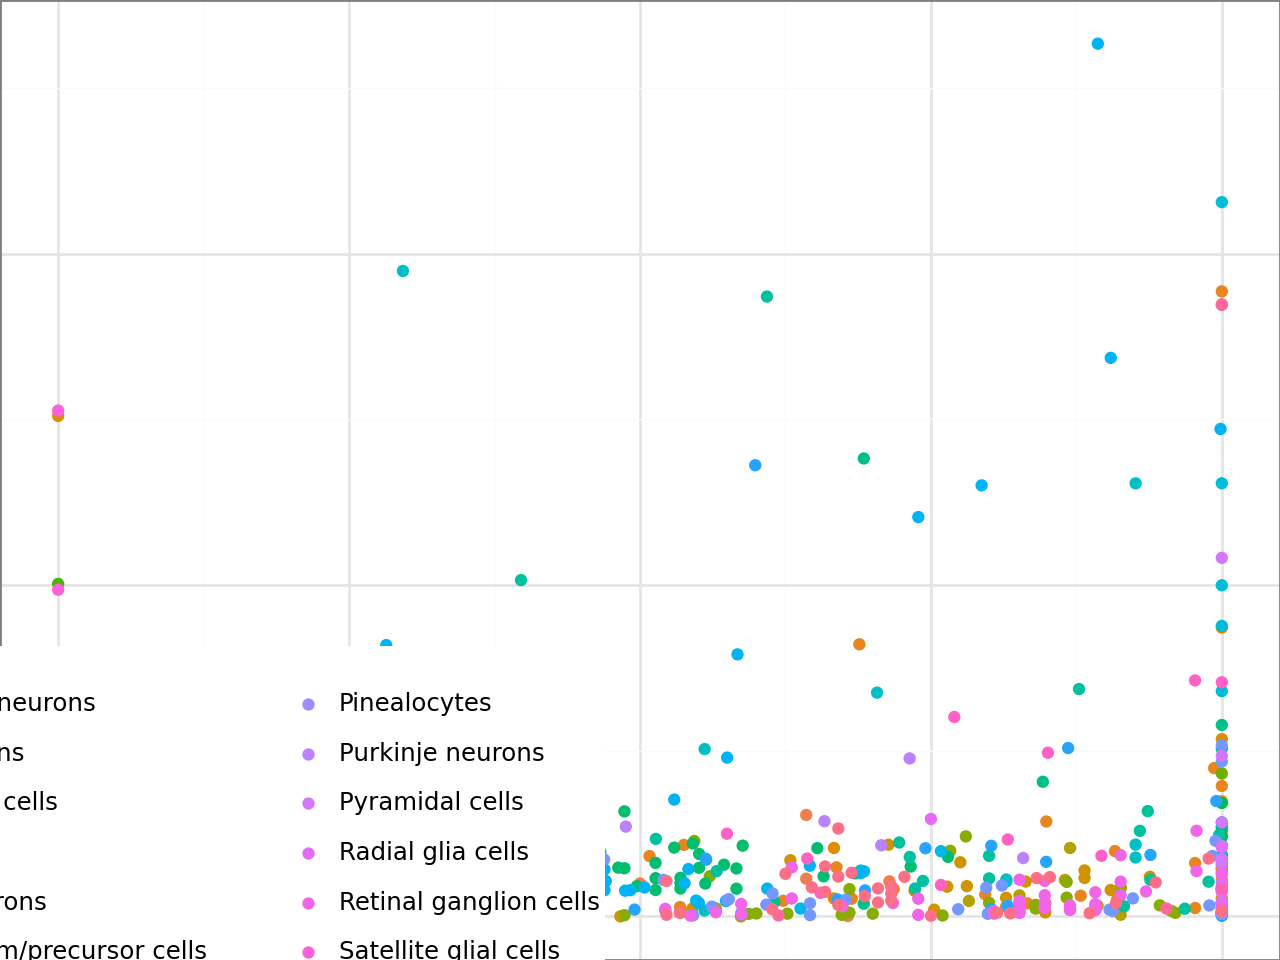

In [119]:

p9.ggplot(brain_markers.fillna(0.), p9.aes(x="sensitivity_mouse", y="specificity_mouse", color = "cell type")) + p9.geom_point()

In [120]:
from collections import Counter
ct_counter = Counter() 
cell_type_anno = []
num_clusters = marker_names.shape[1]
for i in range(num_clusters):
    temp = pd.DataFrame({"gene":marker_names.iloc[:,i].str.upper(), "score":marker_scores.iloc[:,i]})
    temp = temp.merge(brain_markers_filt, on = "gene", how = "inner")
    res = temp.groupby('cell type').agg({'score': 'mean'}).sort_values(by='score', ascending=False)
    #print(res)
    ct = res.index[0]
    cell_type_anno.append(ct + ("" if (ct_counter[ct]==0) else "_%i"%(ct_counter[ct]+1)))
    ct_counter[ct] += 1

In [121]:
adata.obs.leiden = adata.obs.leiden.cat.rename_categories(cell_type_anno)

In [122]:
adata.obs.leiden

720            Pyramidal cells_5
733            Pyramidal cells_4
734            GABAergic neurons
736            Pyramidal cells_2
745                      Neurons
                   ...          
618342    Retinal ganglion cells
618486           Pyramidal cells
628475           Pyramidal cells
628747           Pyramidal cells
628904          Immature neurons
Name: leiden, Length: 112249, dtype: category
Categories (34, object): ['Pyramidal cells', 'Immature neurons', 'GABAergic neurons', 'Pyramidal cells_2', ..., 'Microglia', 'Tanycytes', 'Pyramidal cells_7', 'Immature neurons_4']

In [123]:
mouse_markers

,species,gene,cell type,nicknames,ubiquitousness index,product description,gene type,canonical marker,germ layer,organ,sensitivity_human,sensitivity_mouse,specificity_human,specificity_mouse
0,Mm Hs,CTRB1,Acinar cells,CTRB,0.017,chymotrypsinogen B1,protein-coding gene,1.0,Endoderm,Pancreas,1.000000,0.957143,0.000629,0.015920
1,Mm Hs,KLK1,Acinar cells,Klk6,0.013,kallikrein 1,protein-coding gene,1.0,Endoderm,Pancreas,0.833333,0.314286,0.005031,0.012826
2,Mm Hs,RBPJL,Acinar cells,RBP-L|SUHL|RBPSUHL,0.001,recombination signal binding protein for immun...,protein-coding gene,1.0,Endoderm,Pancreas,0.000000,0.000000,0.000000,0.000000
3,Mm Hs,PTF1A,Acinar cells,PTF1-p48|bHLHa29,0.001,pancreas associated transcription factor 1a,protein-coding gene,1.0,Endoderm,Pancreas,0.000000,0.157143,0.000629,0.000773
4,Mm,TRY4,Acinar cells,NaN,0.007,trypsin 4,protein coding gene,1.0,Endoderm,Pancreas,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8281,Mm Hs,MYH11,Vascular smooth muscle cells,SMMHC|SMHC,0.015,myosin heavy chain 11,protein-coding gene,NaN,Mesoderm,Smooth muscle,0.000000,1.000000,0.016291,0.014697
8282,Mm Hs,PDGFRB,Vascular smooth muscle cells,JTK12|CD140b|PDGFR1|PDGFR,0.033,platelet derived growth factor receptor beta,protein-coding gene,NaN,Mesoderm,Smooth muscle,0.000000,0.750000,0.036341,0.033246
8283,Mm Hs,SEMA3D,Vascular smooth muscle cells,coll-2|Sema-Z2,0.005,semaphorin 3D,protein-coding gene,NaN,Mesoderm,Smooth muscle,0.000000,0.000000,0.001253,0.000000
8284,Mm Hs,TBX18,Vascular smooth muscle cells,NaN,0.004,T-box 18,protein-coding gene,NaN,Mesoderm,Smooth muscle,0.000000,0.000000,0.000313,0.000000
